# Household Energy Consumption Prediction

## Problem Statement

The objective of this project is to predict household appliance energy consumption
using environmental, weather, temperature, humidity, lighting, and other measured
features.

This is formulated as a supervised regression problem where:

- Input: Household environmental and weather related features
- Target: Appliances energy consumption in Wh
- Dataset: UCI Appliances Energy Prediction Dataset

The regression models will be trained and compared using R2, RMSE, and MAE.

## 1. Dataset Description

The Appliances Energy Prediction dataset contains experimental data collected from a low-energy building.

The measurements were recorded at 10-minute intervals for approximately 4.5 months. The dataset contains temperature, humidity, weather, lighting, and appliance energy consumption measurements.

The target variable is `Appliances`, which represents appliance energy consumption in Wh.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [54]:
df = pd.read_csv("energydata.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [55]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 2. Dataset Audit

In [56]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 19735
Number of columns: 29


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


In [59]:
missing_values = df.isnull().sum()

print(missing_values)
print("\nTotal missing values:", missing_values.sum())

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Total missing values: 0


### Missing Value Observation

The dataset contains no missing values. Therefore, no missing-value imputation is required.

In [60]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 3. Target Variable

The target variable for this regression problem is `Appliances`.

It represents household appliance energy consumption measured in Wh.

In [61]:
target = "Appliances"

print("Target variable:", target)
print("Target data type:", df[target].dtype)
print("Target minimum:", df[target].min())
print("Target maximum:", df[target].max())
print("Target mean:", df[target].mean())

Target variable: Appliances
Target data type: int64
Target minimum: 10
Target maximum: 1080
Target mean: 97.6949581960983


## 4. Exploratory Data Analysis (EDA)

### Target Distribution

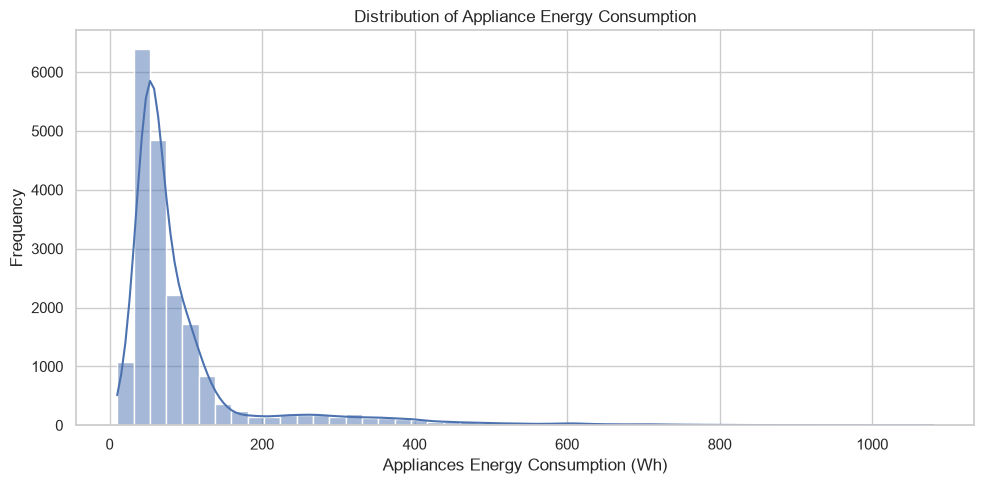

In [62]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Appliances"],
    bins=50,
    kde=True
)

plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Appliances Energy Consumption (Wh)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The target distribution shows how household appliance energy consumption varies across the observations. The shape of the distribution indicates the range and concentration of energy consumption values.

### Feature Distributions

In [63]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_features = [
    col for col in numeric_columns
    if col != "Appliances"
]

print("Number of numerical features:", len(numeric_features))

Number of numerical features: 27


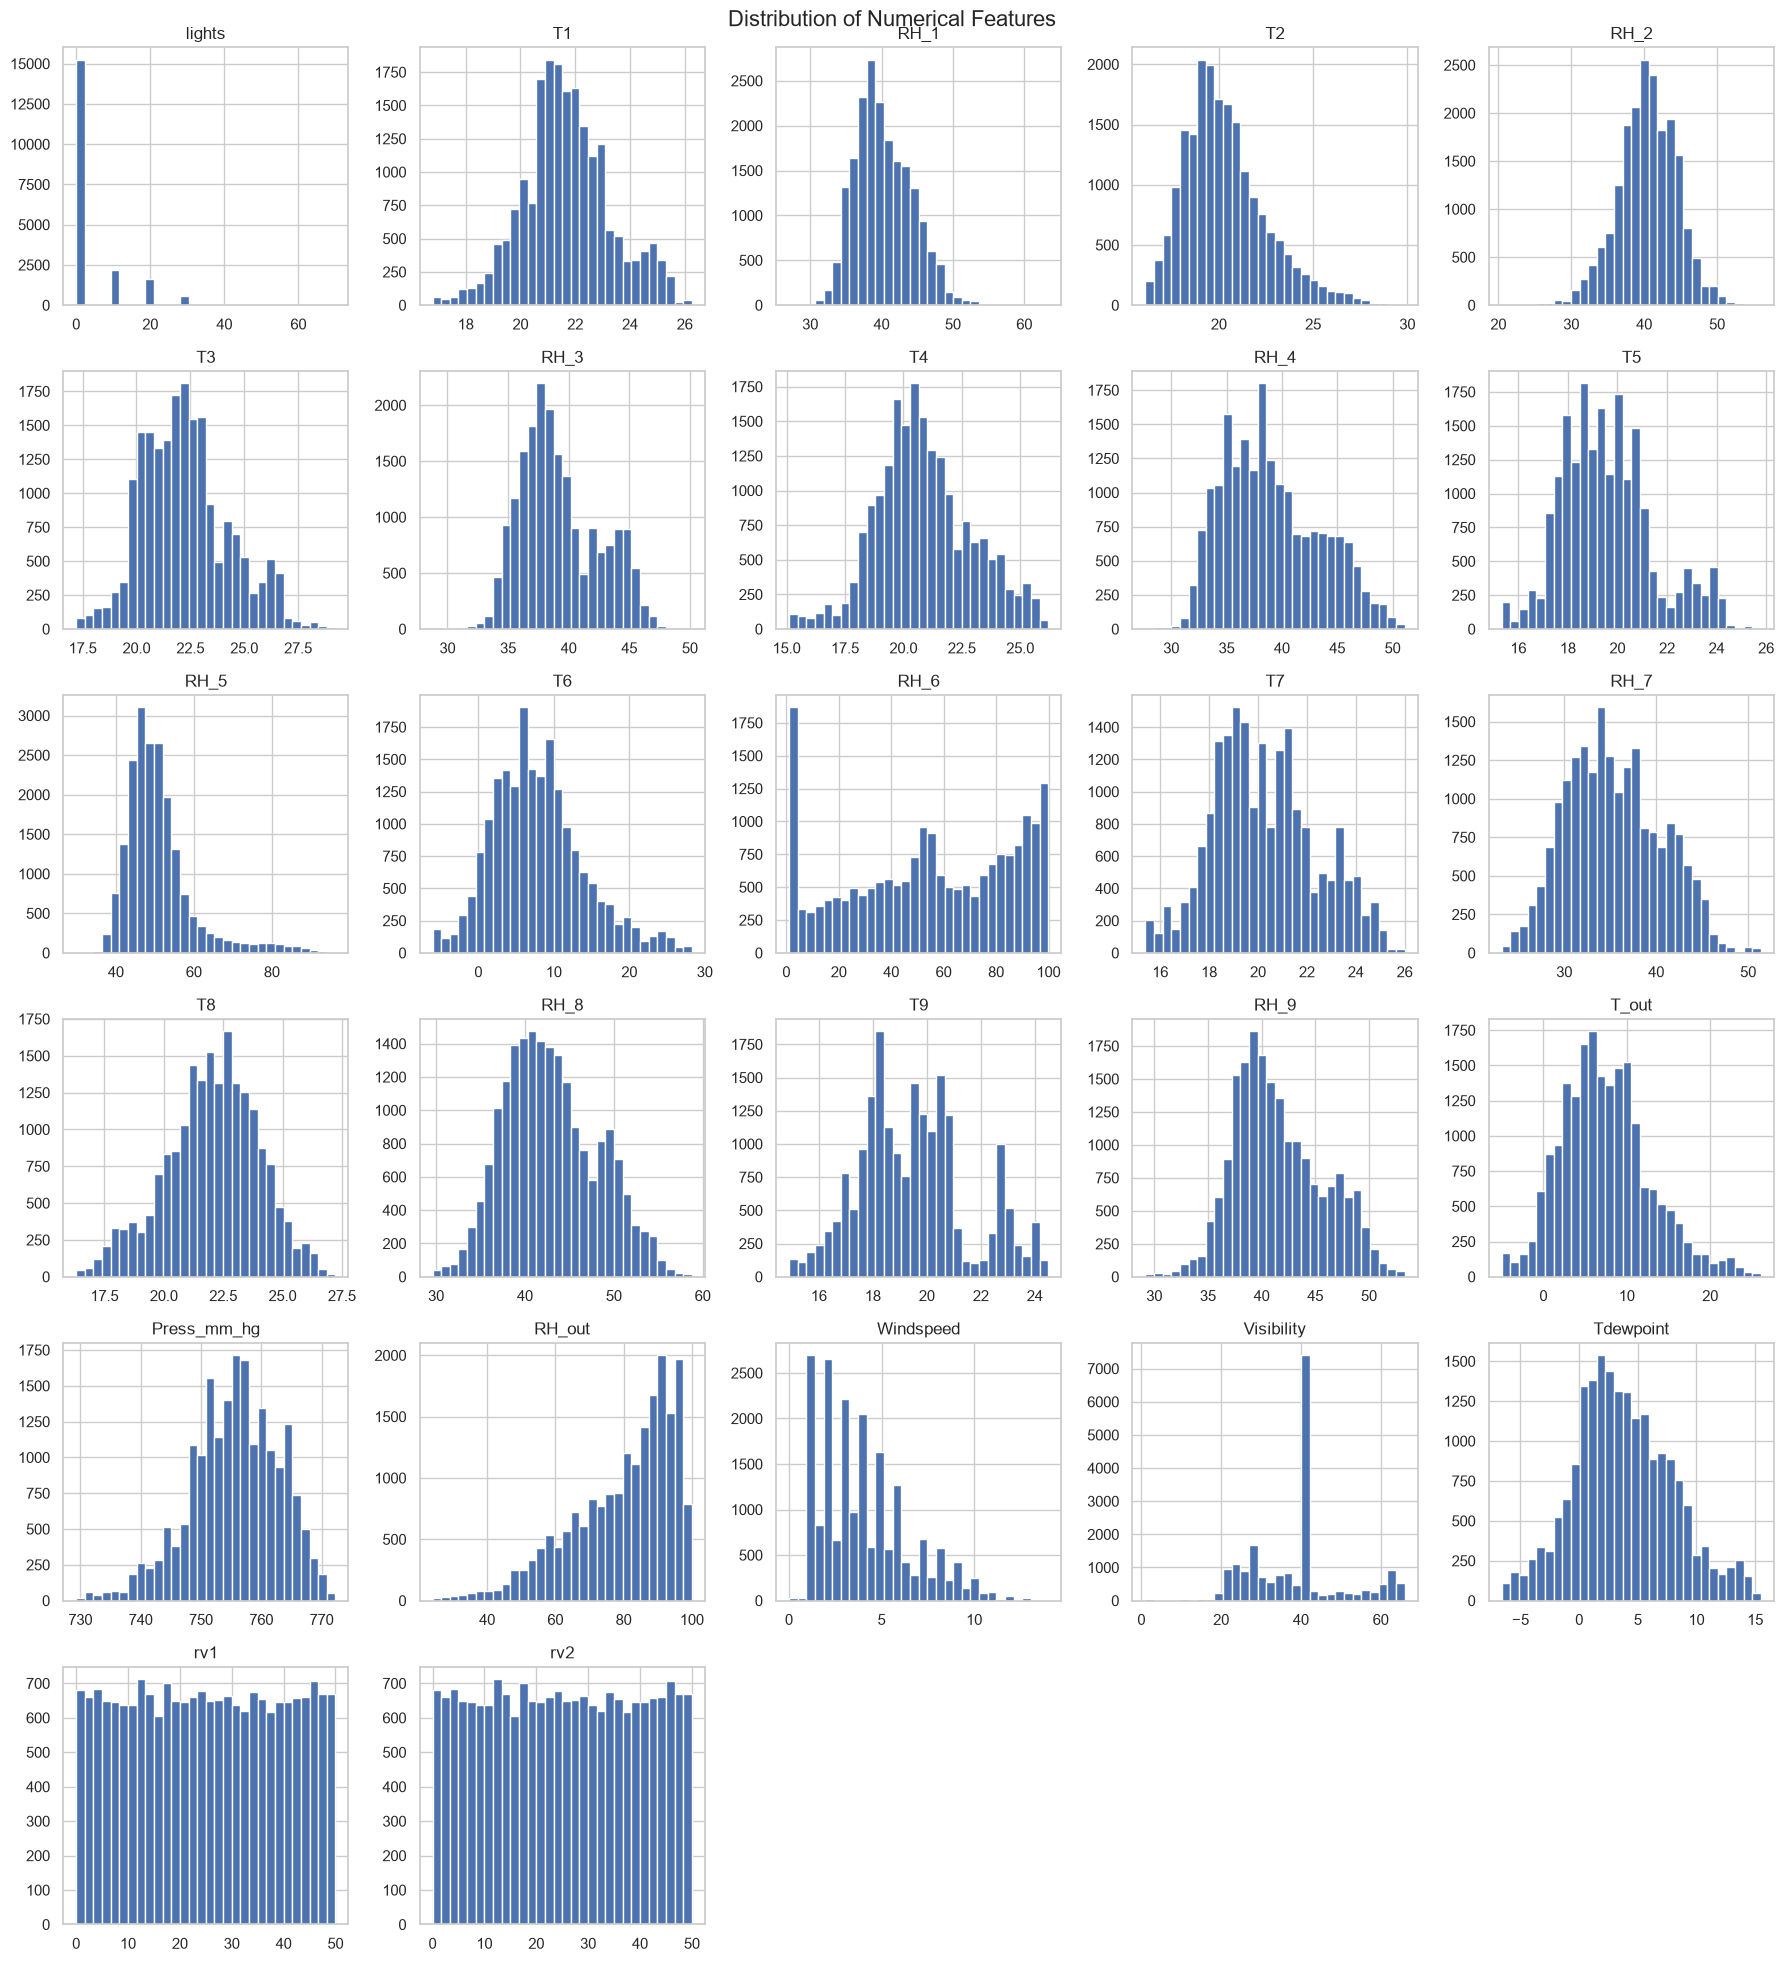

In [64]:
df[numeric_features].hist(
    figsize=(18, 20),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Correlation Analysis

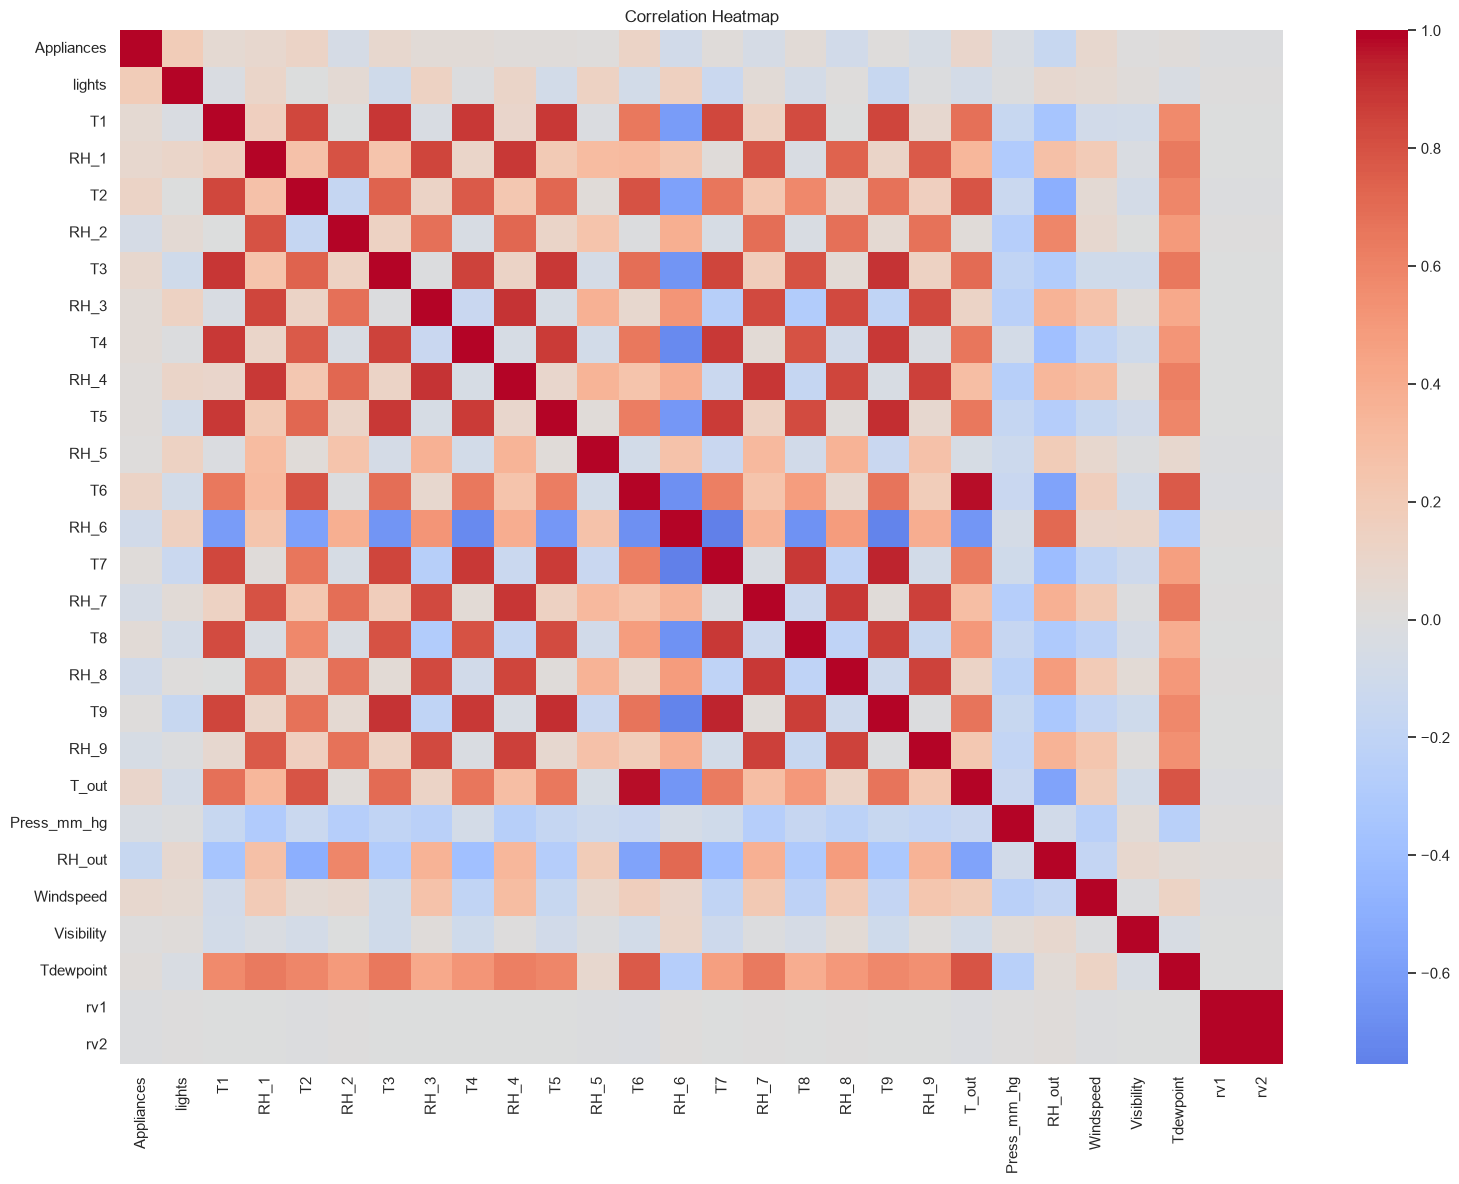

In [65]:
plt.figure(figsize=(16, 12))

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap is used to identify relationships between the numerical features and the target variable. Features with stronger relationships with `Appliances` may provide useful predictive information.

### Feature-Target Relationship 1

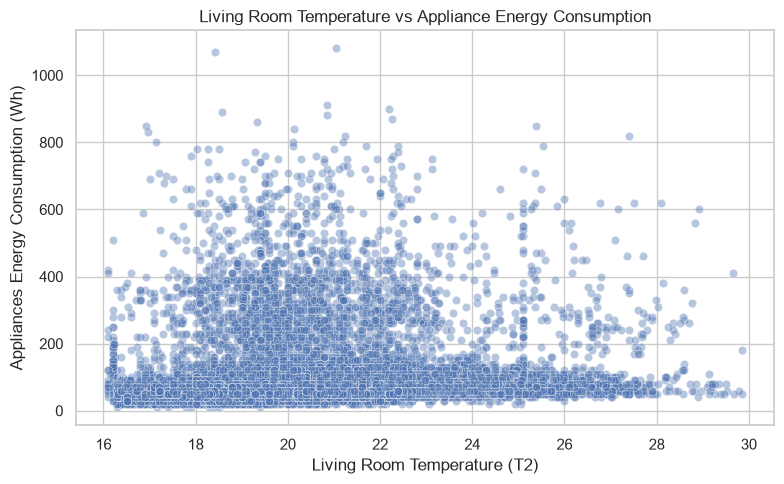

In [66]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="T2",
    y="Appliances",
    alpha=0.4
)

plt.title("Living Room Temperature vs Appliance Energy Consumption")
plt.xlabel("Living Room Temperature (T2)")
plt.ylabel("Appliances Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

### Feature-Target Relationship 2

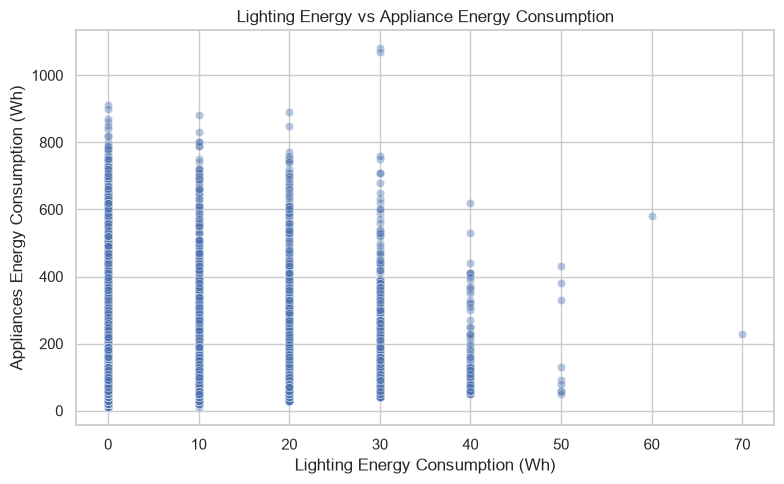

In [67]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="lights",
    y="Appliances",
    alpha=0.4
)

plt.title("Lighting Energy vs Appliance Energy Consumption")
plt.xlabel("Lighting Energy Consumption (Wh)")
plt.ylabel("Appliances Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

## 5. Data Cleaning and Feature Engineering

The original dataset contains a `date` feature. Since machine learning models cannot directly use a raw date string, useful temporal features will be extracted from it.

In [68]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[us]


In [69]:
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print(
    df[
        [
            "date",
            "hour",
            "day_of_week",
            "month",
            "is_weekend"
        ]
    ].head()
)

                 date  hour  day_of_week  month  is_weekend
0 2016-01-11 17:00:00    17            0      1           0
1 2016-01-11 17:10:00    17            0      1           0
2 2016-01-11 17:20:00    17            0      1           0
3 2016-01-11 17:30:00    17            0      1           0
4 2016-01-11 17:40:00    17            0      1           0


In [70]:
# Cyclic Time Features

import numpy as np

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print(
    df[
        [
            "hour",
            "hour_sin",
            "hour_cos",
            "day_sin",
            "day_cos",
            "month_sin",
            "month_cos"
        ]
    ].head()
)

   hour  hour_sin  hour_cos  day_sin  day_cos  month_sin  month_cos
0    17 -0.965926 -0.258819      0.0      1.0        0.5   0.866025
1    17 -0.965926 -0.258819      0.0      1.0        0.5   0.866025
2    17 -0.965926 -0.258819      0.0      1.0        0.5   0.866025
3    17 -0.965926 -0.258819      0.0      1.0        0.5   0.866025
4    17 -0.965926 -0.258819      0.0      1.0        0.5   0.866025


### Removing Random Variables

The dataset contains `rv1` and `rv2`, which are random variables. They are removed because they do not represent meaningful household energy or environmental measurements.

In [71]:
df = df.drop(
    columns=["rv1", "rv2"]
)

print("rv1 and rv2 removed.")

rv1 and rv2 removed.


In [72]:
print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (19735, 37)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025


In [110]:
# Check and Remove Duplicate Rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after duplicate removal:", df.shape)

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Dataset shape after duplicate removal: (19735, 36)


## 6. Feature Matrix and Target

`X` contains the input features and `y` contains the target variable `Appliances`.

In [73]:
X = df.drop(
    columns=["Appliances"]
)

y = df["Appliances"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19735, 36)
y shape: (19735,)


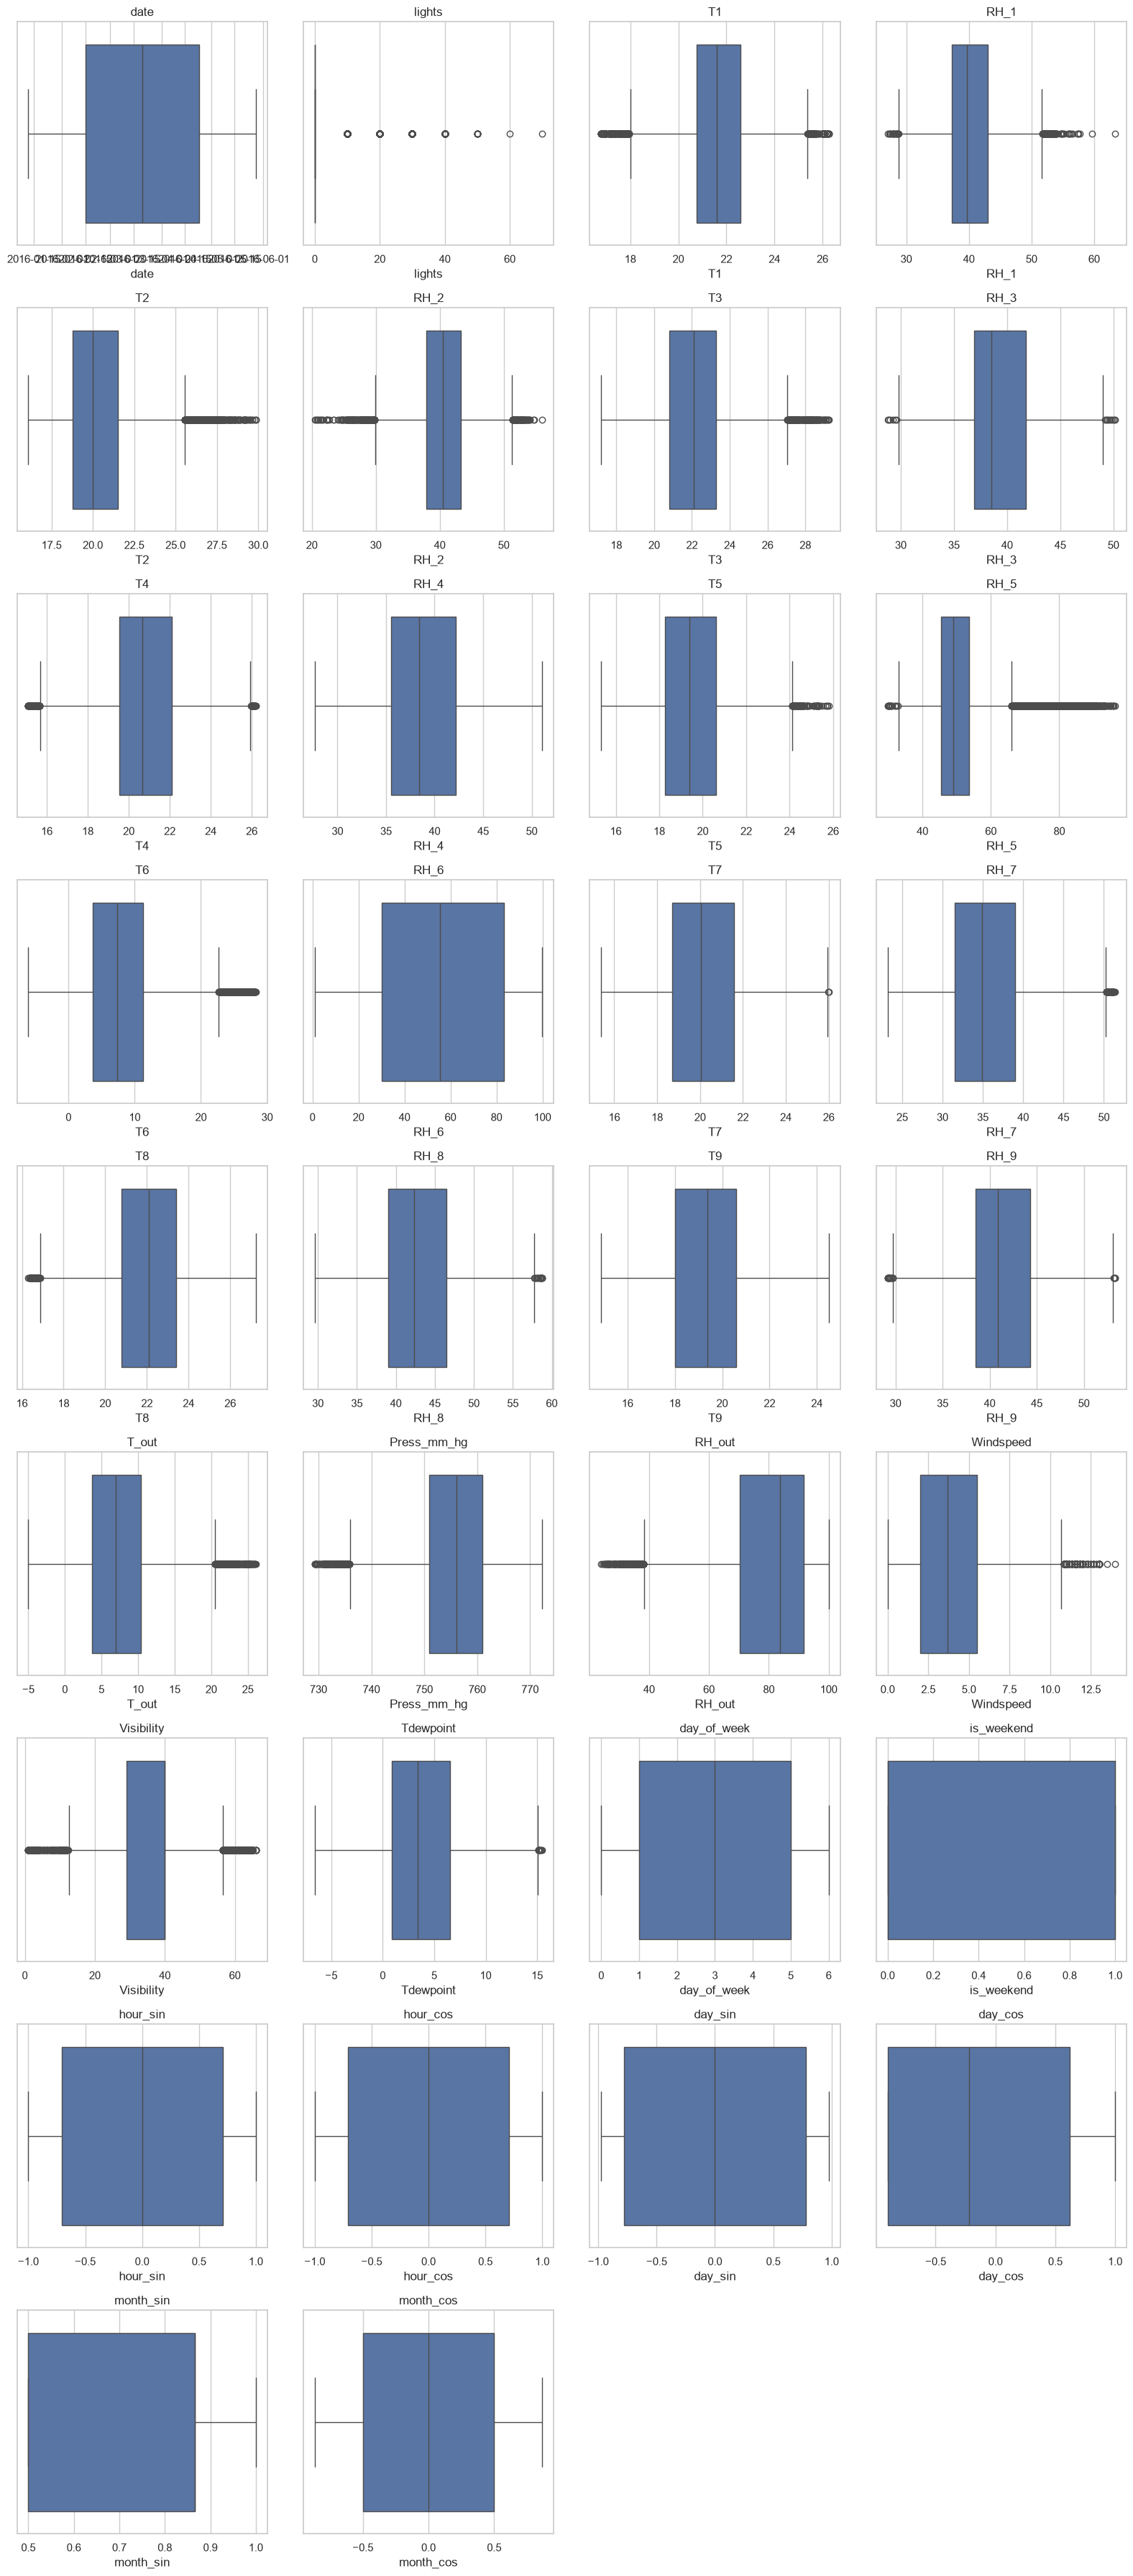

In [74]:
outlier_features = [
    col for col in X.columns
    if col not in ["hour", "day", "month", "weekday"]
]


n_cols = 4
n_rows = int(np.ceil(len(outlier_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(outlier_features):
    sns.boxplot(
        x=X[feature],
        ax=axes[i]
    )
    axes[i].set_title(feature)

for i in range(len(outlier_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [75]:
Q1 = X[outlier_features].quantile(0.25)
Q3 = X[outlier_features].quantile(0.75)

IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outlier_counts = (
    (X[outlier_features] < lower_bound) |
    (X[outlier_features] > upper_bound)
).sum()

outlier_summary = pd.DataFrame({
    "Feature": outlier_features,
    "Outlier Count": outlier_counts.values
})

outlier_summary = outlier_summary.sort_values(
    by="Outlier Count",
    ascending=False
)

outlier_summary

,Feature,Outlier Count
1,lights,4483
24,Visibility,2522
11,RH_5,1330
4,T2,546
2,T1,515
12,T6,515
20,T_out,436
22,RH_out,239
5,RH_2,235
21,Press_mm_hg,219


In [76]:
y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15788, 36)
Testing data: (3947, 36)


In [77]:
print(
    "Training percentage:",
    round(len(X_train) / len(X) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(X_test) / len(X) * 100, 2),
    "%"
)

Training percentage: 80.0 %
Testing percentage: 20.0 %


In [78]:
Q1_train = X_train[outlier_features].quantile(0.25)
Q3_train = X_train[outlier_features].quantile(0.75)

IQR_train = Q3_train - Q1_train

lower_bound_train = Q1_train - 1.5 * IQR_train
upper_bound_train = Q3_train + 1.5 * IQR_train


X_train[outlier_features] = X_train[outlier_features].clip(
    lower=lower_bound_train,
    upper=upper_bound_train,
    axis=1
)


X_test[outlier_features] = X_test[outlier_features].clip(
    lower=lower_bound_train,
    upper=upper_bound_train,
    axis=1
)

print("Outlier treatment completed using IQR capping.")

Outlier treatment completed using IQR capping.


In [79]:
# Remove date from the current dataframe

df = df.drop(columns=["date"])

print("date removed successfully.")
print("Remaining non-numeric columns:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

date removed successfully.
Remaining non-numeric columns:
[]


In [80]:
# Recreate feature matrix and target

X = df.drop(columns=["Appliances"])
y = df["Appliances"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNon-numeric columns in X:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

X shape: (19735, 35)
y shape: (19735,)

Non-numeric columns in X:
[]


In [81]:
# Final 80/20 train-test split

y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15788, 35)
X_test shape: (3947, 35)
y_train shape: (15788,)
y_test shape: (3947,)


# 7. Regression Algorithm 1 — Linear Regression

Linear Regression is used as the baseline regression model. It assumes a linear relationship between the input features and the target variable.

In [82]:
# Train Linear Regression model

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [83]:
# Evaluate Linear Regression

linear_r2 = r2_score(
    y_test,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

print("Linear Regression Results")
print("-------------------------")
print("R²   :", linear_r2)
print("RMSE :", linear_rmse)
print("MAE  :", linear_mae)

Linear Regression Results
-------------------------
R²   : 0.19811799443412526
RMSE : 87.28479004406012
MAE  : 50.105322230547515


# 8. Regression Algorithm 2 — Ridge Regression

Ridge Regression is a linear regression technique that uses L2 regularisation. The regularisation term helps control the magnitude of model coefficients and can reduce the effect of multicollinearity.

Feature scaling is applied before Ridge Regression.

In [86]:
# Train Ridge Regression

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train,
    y_train
)

y_pred_ridge = ridge_model.predict(
    X_test
)

print("Ridge Regression trained successfully.")

Ridge Regression trained successfully.


In [87]:
# Evaluate Ridge Regression

ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)

print("Ridge Regression Results")
print("-------------------------")
print("R²   :", ridge_r2)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)

Ridge Regression Results
-------------------------
R²   : 0.19811670028277506
RMSE : 87.28486047816547
MAE  : 50.096452230229026


# 9. Regression Algorithm 3 — Lasso Regression

Lasso Regression uses L1 regularisation. Unlike ordinary Linear Regression, Lasso can shrink some coefficients to exactly zero, which can result in feature sparsity.

Feature scaling is applied before Lasso Regression.

In [90]:
# Train Lasso Regression

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        alpha=0.01,
        max_iter=10000
    ))
])

lasso_model.fit(
    X_train,
    y_train
)

y_pred_lasso = lasso_model.predict(
    X_test
)

print("Lasso Regression trained successfully.")

Lasso Regression trained successfully.


In [91]:
# Evaluate Lasso Regression

lasso_r2 = r2_score(
    y_test,
    y_pred_lasso
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lasso
    )
)

lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

print("Lasso Regression Results")
print("-------------------------")
print("R²   :", lasso_r2)
print("RMSE :", lasso_rmse)
print("MAE  :", lasso_mae)

Lasso Regression Results
-------------------------
R²   : 0.19813832038413715
RMSE : 87.28368379806024
MAE  : 50.08221991799199


# 10. Regression Algorithm 4 — ElasticNet Regression

ElasticNet Regression combines L1 and L2 regularisation.

The `alpha` parameter controls the overall regularisation strength, while `l1_ratio` determines the balance between L1 and L2 regularisation.

Feature scaling is applied before training the model.

In [95]:
# Train ElasticNet Regression

elastic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000
    ))
])

elastic_model.fit(
    X_train,
    y_train
)

y_pred_elastic = elastic_model.predict(
    X_test
)

print("ElasticNet Regression trained successfully.")

ElasticNet Regression trained successfully.


In [103]:
# Evaluate ElasticNet Regression

elastic_r2 = r2_score(
    y_test,
    y_pred_elastic
)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_elastic
    )
)

elastic_mae = mean_absolute_error(
    y_test,
    y_pred_elastic
)

print("ElasticNet Regression Results")
print("-------------------------")
print("R²   :", elastic_r2)
print("RMSE :", elastic_rmse)
print("MAE  :", elastic_mae)

ElasticNet Regression Results
-------------------------
R²   : 0.19811290401665205
RMSE : 87.2850670893811
MAE  : 50.08990200556634


# 11. Regression Algorithm 5 — Polynomial Regression

Polynomial Regression extends Linear Regression by creating polynomial combinations of the input features.

PolynomialFeatures is applied before Linear Regression. Different polynomial degrees are compared to investigate whether modelling nonlinear relationships improves prediction performance.

In [106]:
# Train Polynomial Regression with degree 2

poly_model = Pipeline([
    (
        "polynomial",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "linear",
        LinearRegression()
    )
])

poly_model.fit(
    X_train,
    y_train
)

y_pred_poly = poly_model.predict(
    X_test
)

print("Polynomial Regression trained successfully.")

Polynomial Regression trained successfully.


In [107]:
# Evaluate Polynomial Regression

poly_r2 = r2_score(
    y_test,
    y_pred_poly
)

poly_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_poly
    )
)

poly_mae = mean_absolute_error(
    y_test,
    y_pred_poly
)

print("Polynomial Regression Results")
print("-------------------------")
print("R²   :", poly_r2)
print("RMSE :", poly_rmse)
print("MAE  :", poly_mae)

Polynomial Regression Results
-------------------------
R²   : 0.3640411656112468
RMSE : 77.73164167020182
MAE  : 46.26478299548383
